In [5]:
# declare libraries
import json
import geojson
import pathlib
import time
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely

import pprint as pp

from zipfile import ZipFile
import rioxarray as rxr
import xarray as xr
import rasterio as rio
from rasterio.plot import show

import matplotlib.pyplot as plt

import requests
from requests.auth import HTTPBasicAuth
from planet import Session, DataClient, OrdersClient, Auth, Planet

import os
import sys

from rasterio.warp import calculate_default_transform, reproject, Resampling

sys.path.append("../utils")

In [6]:
path = "/capstone/wildfire_prep/data/stress_test/files/"

# 20220502_174416_40_2445_3B_AnalyticMS_SR_clip_bandmath.tif


ndvi_list = []
for file in os.listdir(path=path):
    if "AnalyticMS_SR_clip_bandmath.tif" in file:
        ndvi_list.append(f"{path}{file}")

ndvi_list[0]

'/capstone/wildfire_prep/data/stress_test/files/20220524_182146_44_2446_3B_AnalyticMS_SR_clip_bandmath.tif'

In [40]:
# for i in range(len(ndvi_list)):

#     with rio.open(ndvi_list[i]) as src:
#         ndvi = src.read([1,2,3]).transpose([1,2,0])

    
#     plt.figure(figsize=(10, 6))
#     plt.imshow(ndvi)  # Apply colormap
#     plt.colorbar(label="NDVI")           # Add a color bar
#     plt.title("NDVI Visualization")
#     plt.xlabel("Longitude")
#     plt.ylabel("Latitude")
#     plt.show()


In [8]:
# plt.figure(figsize=(10, 6))
# plt.imshow(ndvi, cmap='RdYlGn')  # Apply colormap
# plt.colorbar(label="NDVI")           # Add a color bar
# plt.title("NDVI Visualization")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.show()


In [ ]:
# rgb_list = []
# for file in os.listdir(path = path):
#     if "3B_udm2_clip.tif" in file:
#         rgb_list.append(f"{path}{file}")

# rgb_list

['/capstone/wildfire_prep/data/stress_test/files/20220519_174814_10_2465_3B_udm2_clip.tif',
 '/capstone/wildfire_prep/data/stress_test/files/20220516_174826_70_245c_3B_udm2_clip.tif',
 '/capstone/wildfire_prep/data/stress_test/files/20220502_175124_90_241f_3B_udm2_clip.tif',
 '/capstone/wildfire_prep/data/stress_test/files/20220520_181314_02_2231_3B_udm2_clip.tif',
 '/capstone/wildfire_prep/data/stress_test/files/20220506_182136_31_248f_3B_udm2_clip.tif',
 '/capstone/wildfire_prep/data/stress_test/files/20220519_181824_40_248b_3B_udm2_clip.tif',
 '/capstone/wildfire_prep/data/stress_test/files/20220512_184124_16_2407_3B_udm2_clip.tif',
 '/capstone/wildfire_prep/data/stress_test/files/20220512_174941_93_2420_3B_udm2_clip.tif',
 '/capstone/wildfire_prep/data/stress_test/files/20220524_181016_82_2231_3B_udm2_clip.tif',
 '/capstone/wildfire_prep/data/stress_test/files/20220516_174828_98_245c_3B_udm2_clip.tif',
 '/capstone/wildfire_prep/data/stress_test/files/20220526_180826_59_2233_3B_udm2

In [10]:
ndvi_test = rxr.open_rasterio(ndvi_list[0])
ndvi_test.sel(band = 5)


<xarray.DataArray (y: 1279, x: 1901)> Size: 5MB
[2431379 values with dtype=uint16]
Coordinates:
    band         int64 8B 5
  * x            (x) float64 15kB 7.664e+05 7.664e+05 ... 7.721e+05 7.721e+05
  * y            (y) float64 10kB 3.844e+06 3.844e+06 ... 3.84e+06 3.84e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

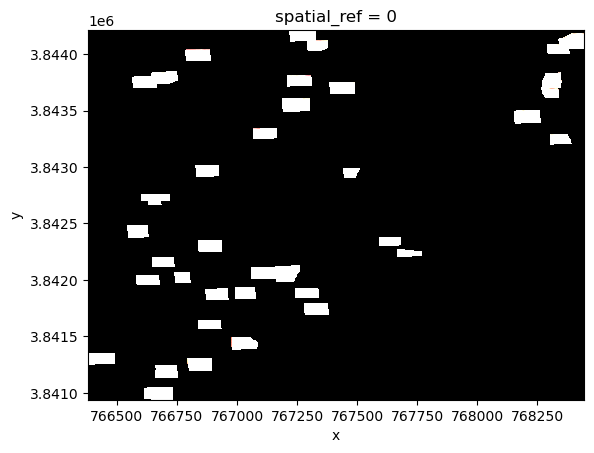

In [11]:


for tif_name in ndvi_list:
    test_rast = rxr.open_rasterio(tif_name)

    r = test_rast.sel(band = 4)
    g = test_rast.sel(band = 3)
    b = test_rast.sel(band = 2)

    # Normalize the bands to [0, 1] for visualization
    # red_norm = (r - r.min()) / (r.max() - r.min())
    # green_norm = (g - g.min()) / (g.max() - g.min())
    # blue_norm = (b - b.min()) / (b.max() - b.min())

    # Stack the bands into an RGB image
    # rgb_image = np.dstack((r, g, b))
    rgb_image = xr.concat([r, g, b], dim="band").transpose("y", "x", "band")


    rgb_image.plot.imshow(robust=True)

    # plt.figure(figsize=(10, 8))
    # plt.imshow(rgb_image)
    # plt.title("RGB GeoTIFF Visualization")
    # plt.axis("off")  # Turn off the axes for better visualization
    # plt.show()


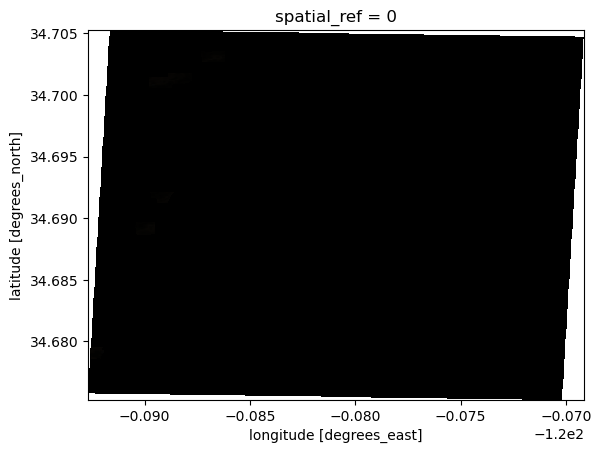

In [12]:

for tif_name in ndvi_list:
    test_rast = rxr.open_rasterio(tif_name)

    r = test_rast.sel(band = 3)
    g = test_rast.sel(band = 2)
    b = test_rast.sel(band = 1)

    # Normalize the bands to [0, 1] for visualization
    # red_norm = (r - r.min()) / (r.max() - r.min())
    # green_norm = (g - g.min()) / (g.max() - g.min())
    # blue_norm = (b - b.min()) / (b.max() - b.min())

    # Stack the bands into an RGB image
    # rgb_image = np.dstack((r, g, b))
    rgb_image = xr.concat([r, g, b], dim="band").transpose("band", "y", "x")
    
    rgb_image = rgb_image.rio.reproject("EPSG:4326")



    rgb_image.plot.imshow(robust=True)

    # plt.figure(figsize=(10, 8))
    # plt.imshow(rgb_image)
    # plt.title("RGB GeoTIFF Visualization")
    # plt.axis("off")  # Turn off the axes for better visualization
    # plt.show()


In [35]:
rgb_image[0].to_masked_array()[0]

masked_array(data=[65535, 65535, 65535, 65535, 65535, 65535, 65535, 65535,
                   65535, 65535, 65535, 65535, 65535, 65535, 65535, 65535,
                   65535, 65535, 65535, 65535, 65535, 65535, 65535, 65535,
                   65535, 65535, 65535, 65535, 65535, 65535, 65535, 65535,
                   65535, 65535, 65535, 65535, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 65535, 65535,
                   65535, 65535, 65535, 65535, 65535, 65535, 65535, 65535,
                   65535, 65535, 65535, 65535, 65535, 65535, 65535, 65535,
                   65535, 65535, 65535, 65535, 65535, 65535, 65535, 65535,
                   65535, 65535, 65535, 65535, 65535, 65535, 65535, 65535,
                   65535, 65535, 65535, 65535, 65535, 65535, 65535, 65535,
                   65535, 65535, 65535, 65535, 65535, 65535, 65535, 65535,
                   65535, 65535, 65535, 65535, 65535, 65535, 65535, 65535,
                   65535, 65535,

In [13]:
print(rgb_image.rio.crs)
print(rgb_image.rio.bounds())

EPSG:4326
(-120.09268546441955, 34.67526810061661, -120.06913776048543, 34.7052821242216)


In [14]:
with rio.open(ndvi_list[0]) as src: 
    print(f"CRS: {src.crs}")
    print(f"Bounds: {src.bounds}")
    print(f"Width/Height: {src.width}/{src.height}")
    print(f"left bounds: {src.bounds[0]}")
    print(f"bottom bounds: {src.bounds[1]}")
    print(f"right bounds: {src.bounds[2]}")
    print(f"top bounds: {src.bounds[3]}")
    transform, width, height = calculate_default_transform(
        src_crs = src.crs,
        dst_crs = "EPSG:4326",
        width = src.width, height = src.height,
        left = src.bounds[0],
        bottom = src.bounds[1], 
        right = src.bounds[2], 
        top = src.bounds[3]
    )

    kwargs = src.meta.copy()
    kwargs.update({
        "crs": "EPSG:4326", 
        "transform": transform,
        "width": width,
        "height": height
    })

    # Write reprojected file
    with rio.open("/capstone/wildfire_prep/data/stress_test/test_reproject/test_reprojected_planet.tif", "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source = rio.band(src, i),
                destination = rio.band(dst, i),
                src_transform = src.transform,
                src_crs = src.crs,
                dst_transform = transform,
                dst_crs = "EPSG:4326",
                resampling = Resampling.nearest
            )

CRS: EPSG:32610
Bounds: BoundingBox(left=766380.0, bottom=3840375.0, right=772083.0, top=3844212.0)
Width/Height: 1901/1279
left bounds: 766380.0
bottom bounds: 3840375.0
right bounds: 772083.0
top bounds: 3844212.0


In [15]:
with rio.open("/capstone/wildfire_prep/data/stress_test/test_reproject/test_reprojected_planet.tif") as src:
    repoj = src.read()

In [16]:
# Get the dimensions
bands, height, width = repoj.shape
print(f"Image shape: {repoj.shape}")

# Generate pixel coordinate arrays
y_indices, x_indices = np.arange(height), np.arange(width)


# Calculate longitude (x) and latitude (y) values
lon = transform.c + x_indices * transform.a  # Longitude array
lat = transform.f + y_indices * transform.e  # Latitude array

# Transpose the data from (bands, height, width) to (height, width, bands)
full_data = np.transpose(repoj, (1, 2, 0))  # Shape: (height, width, bands)

Image shape: (5, 1166, 2051)


In [17]:
# make the xarray.DataArray
full_xr = xr.DataArray(
    data = full_data,
    dims = ("lat", "lon", "band"),
    coords = {
        "lat": lat,  # Latitude values
        "lon": lon,  # Longitude values
        "band": ["blue", "green", "red", "nir", "ndvi"]  # Band names
    },
    attrs = {
        "crs": "EPSG:4326",  # Add CRS as metadata
        "description": "Test array."
    }
)

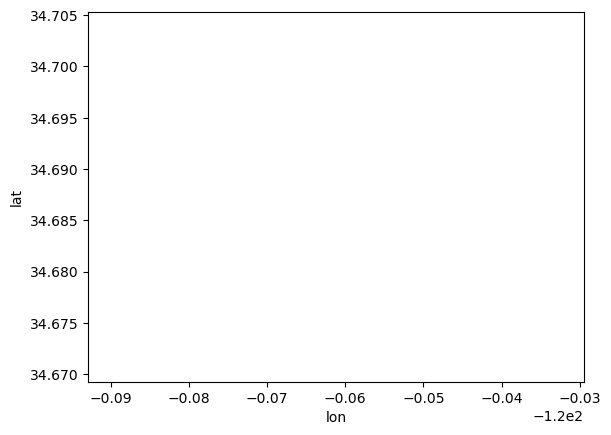

In [18]:
full_xr.sel(band = ["blue", "green", "red"]).plot.imshow(robust= True)

In [84]:
# Load a GeoTIFF
data = rxr.open_rasterio("/capstone/wildfire_prep/data/stress_test/files/20220502_174416_40_2445_3B_AnalyticMS_SR_clip_bandmath.tif")

print(data.rio.nodata)  # Check current nodata value
data = data.astype("float32")
data = data.rio.write_nodata(-9999)  # Set nodata value (example: -9999)

# reproject
data = data.rio.reproject("EPSG:4326") 

# Plot the data
# data.plot.imshow(robust = True)
# plt.title("GeoTIFF Visualization")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.show()

None


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9999.0..3019.0].


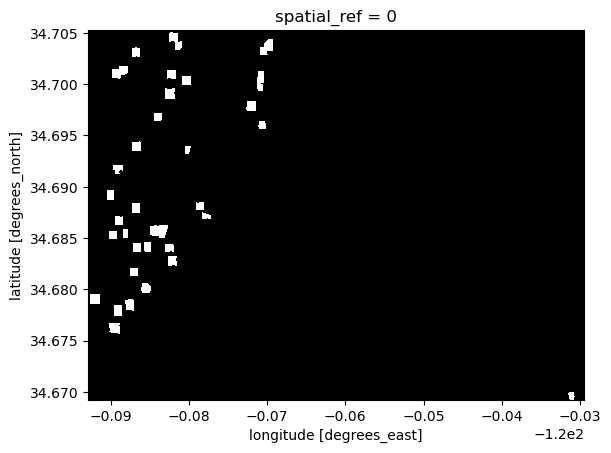

In [91]:
data.squeeze()[0:3].plot.imshow()

In [90]:
np.unique(data.values)

array([-9999.,     0.,   329., ...,  3951.,  3968.,  3996.], dtype=float32)

In [85]:
data

<xarray.DataArray (band: 5, y: 1166, x: 2051)> Size: 48MB
array([[[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        ...,
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],

       [[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        ...,
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],

       [[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        ...,
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],

       [[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        ...,
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],

       [[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        ...,
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.]]],
      dtype=float32)
Coordinates:
  * x            (x) float64 16kB -120.1 -120.1 -120.1 ... -120.0 -120.0 -120.0
  * y            (y) float64 9kB 34.71 34.71 34.71 34.71 ... 34.67 34.67 34.67
  * band         (band) int64 40B 1 2 3 4 5
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     -9999.0

In [ ]:
tif_fp = "/capstone/wildfire_prep/data/stress_test/files/20220502_175124_90_241f_3B_AnalyticMS_SR_clip_bandmath.tif"
nc_convert_fp = "/capstone/wildfire_prep/data/stress_test/test_nc_convert/test_convert.nc"

with rxr.open_rasterio(tif_fp) as tif:
    tif.to_netcdf(nc_convert_fp, format = "netcdf4")

In [123]:
print(os.access("/capstone/wildfire_prep/data/stress_test/test_nc_convert", os.W_OK))

True


In [148]:
nc = xr.open_dataset(nc_convert_fp)

nc_da = nc.drop_vars("spatial_ref").to_dataarray()#.drop_indexes("variable").squeeze().sel(band = [3,2,1])

normalized_data = (nc_da - nc_da.min()) / (nc_da.max() - nc_da.min())

In [192]:
lon_min, lon_max = data.x.min().item(), data.x.max().item()
lat_min, lat_max = data.y.min().item(), data.y.max().item()

lon_array = [lon_min, lon_max]
lat_array = [lat_min, lat_max]

lon_values = np.linspace(lon_min, lon_max, normalized_data.sizes["x"])
lat_values = data.y.values
normalized_data = normalized_data.assign_coords(lon=lon_values)

print(lon_array)
print(lat_array)
print(data.x.values)

ValueError: cannot add coordinates with new dimensions to a DataArray

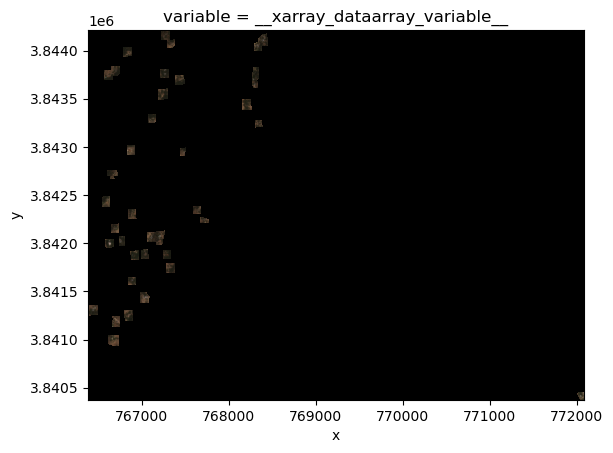

In [185]:
normalized_data.sel(band = [3,2,1]).squeeze().plot.imshow()

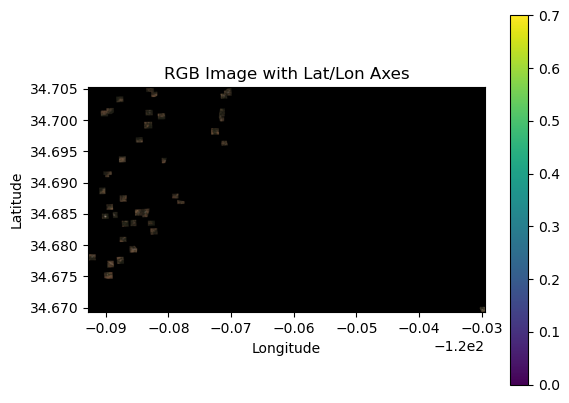

In [186]:
rgb_image = np.moveaxis(normalized_data.sel(band=[3, 2, 1]).squeeze().values, 0, -1)

plt.imshow(rgb_image, 
           extent=[lon_min, lon_max, lat_min, lat_max], 
           cmap="viridis")
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("RGB Image with Lat/Lon Axes")
plt.show()


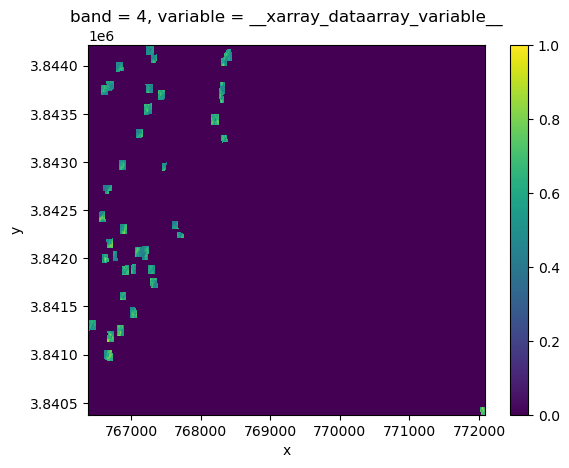

In [172]:
normalized_data.sel(band = [4]).squeeze().plot.imshow()

In [168]:
print(float( data.x.min() ))
print(float( data.x.max() ))
print(float( data.y.min() ))
print(float( data.y.max() ))

-120.09284764337485
-120.02948087819662
34.66925579992149
34.70526666891302


In [137]:
help(nc.drop_vars("spatial_ref").to_dataarray().drop_indexes("variable").sel)

Help on method sel in module xarray.core.dataarray:

sel(indexers: 'Mapping[Any, Any] | None' = None, method: 'str | None' = None, tolerance=None, drop: 'bool' = False, **indexers_kwargs: 'Any') -> 'Self' method of xarray.core.dataarray.DataArray instance
    Return a new DataArray whose data is given by selecting index
    labels along the specified dimension(s).

    In contrast to `DataArray.isel`, indexers for this method should use
    labels instead of integers.

    Under the hood, this method is powered by using pandas's powerful Index
    objects. This makes label based indexing essentially just as fast as
    using integer indexing.

    It also means this method uses pandas's (well documented) logic for
    indexing. This means you can use string shortcuts for datetime indexes
    (e.g., '2000-01' to select all values in January 2000). It also means
    that slices are treated as inclusive of both the start and stop values,
    unlike normal Python indexing.

    .. warning:

In [ ]:
nc.sel(band = [3,2,1]).plot.imshow()

# nx_dr = xr.open_dataarray(nc_convert_fp)

ValueError: Given file dataset contains more than one data variable. Please read with xarray.open_dataset and then select the variable you want.

In [118]:
help(tif.to_netcdf)

Help on method to_netcdf in module xarray.core.dataarray:

to_netcdf(path: 'str | PathLike | None' = None, mode: 'NetcdfWriteModes' = 'w', format: 'T_NetcdfTypes | None' = None, group: 'str | None' = None, engine: 'T_NetcdfEngine | None' = None, encoding: 'Mapping[Hashable, Mapping[str, Any]] | None' = None, unlimited_dims: 'Iterable[Hashable] | None' = None, compute: 'bool' = True, invalid_netcdf: 'bool' = False, auto_complex: 'bool | None' = None) -> 'bytes | Delayed | None' method of xarray.core.dataarray.DataArray instance
    Write DataArray contents to a netCDF file.

    Parameters
    ----------
    path : str, path-like or None, optional
        Path to which to save this dataset. File-like objects are only
        supported by the scipy engine. If no path is provided, this
        function returns the resulting netCDF file as bytes; in this case,
        we need to use scipy, which does not support netCDF version 4 (the
        default format becomes NETCDF3_64BIT).
    mode 